In [235]:
# 필요한 라이브러리 import
import pandas as pd 
import numpy as np
import time
from PIL import Image

import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt 

In [236]:
# 파일에서 데이터 불러오기
df1 = pd.read_csv("/Users/joshuakim/Desktop/Python Data/project 1 data/seoul_real_estate_dataset/2018.csv", encoding="euc-kr",low_memory = False)
df2 = pd.read_csv("/Users/joshuakim/Desktop/Python Data/project 1 data/seoul_real_estate_dataset/2019.csv", encoding="euc-kr",low_memory = False)
df3 = pd.read_csv("/Users/joshuakim/Desktop/Python Data/project 1 data/seoul_real_estate_dataset/2020.csv", encoding="euc-kr",low_memory = False)
df4 = pd.read_csv("/Users/joshuakim/Desktop/Python Data/project 1 data/seoul_real_estate_dataset/2021.csv", encoding="euc-kr",low_memory = False)
df5 = pd.read_csv("/Users/joshuakim/Desktop/Python Data/project 1 data/seoul_real_estate_dataset/2022.csv", encoding="euc-kr",low_memory = False) 
df6 = pd.read_csv("/Users/joshuakim/Desktop/Python Data/project 1 data/seoul_real_estate_dataset/2023.csv", encoding="euc-kr",low_memory = False)
df7 = pd.read_csv("/Users/joshuakim/Desktop/Python Data/project 1 data/seoul_real_estate_dataset/2024.csv", encoding="euc-kr",low_memory = False)

In [237]:
# 시각화시 한글 깨짐 방지
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False 

In [238]:
# 모든 데이터를 dfs 하나의 리스트로 만든 후 데이터 크기 확인하기
dfs = [df1, df2, df3, df4, df5, df6, df7]
df_all = pd.concat(dfs, axis=0, ignore_index=True, join = 'inner')
print(df_all.shape)

(833614, 21)


In [239]:
# 거래 취소건 데이터에서 제거
# 제거후 데이터 크기
df_all = df_all[df_all["취소일"].isna()]
print("거래 취소 건 제거 후:", df_all.shape)

거래 취소 건 제거 후: (808073, 21)


In [240]:
# 가격 이상치 제거 
# 가격 이상치 제거후 데이터 크기

Q1 = df_all["물건금액(만원)"].quantile(0.25)
Q3 = df_all["물건금액(만원)"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_all = df_all[(df_all["물건금액(만원)"] >= lower) & (df_all["물건금액(만원)"] <= upper)]
print("거래금액 이상치 제거 후:", df_all.shape)

거래금액 이상치 제거 후: (757070, 21)


In [241]:
# 건축연도 정제 및 정제 후 데이터 크기

df_all = df_all.copy()
df_all["건축년도"] = pd.to_numeric(df_all["건축년도"], errors="coerce")
current_year = pd.Timestamp.today().year

df_all = df_all[(df_all["건축년도"] >= 1900) & (df_all["건축년도"] <= current_year)]
print("건축연도 정제 후:", df_all.shape)

건축연도 정제 후: (747374, 21)


In [242]:
# 건물 
df_all["건물면적(㎡)"] = pd.to_numeric(df_all["건물면적(㎡)"], errors="coerce")

# 평수 및 평수당 가격 구하기
df_all["평수"] = df_all["건물면적(㎡)"] / 3.3
df_all["평당가격"] = df_all["물건금액(만원)"] / df_all["평수"]

# print(df_all[["건물면적(㎡)", "평수", "물건금액(만원)", "평당가격"]].head())

# 연도별 평균 평당 가격
avg_py_year = (df_all.groupby("접수연도")["평당가격"].mean().reset_index())
avg_py_year["평당가격"] = avg_py_year["평당가격"].round(1)
print(avg_py_year)

   접수연도    평당가격
0  2018  2271.4
1  2019  2587.3
2  2020  2742.6
3  2021  2936.6
4  2022  2891.1
5  2023  3317.8
6  2024  3552.5


In [243]:
# 데이터 계약 연도, 월 분리 ????????????

df_all = df_all.copy()
df_all["계약일"] = pd.to_datetime(df_all["계약일"], errors="coerce", format="%Y%m%d")
df_all["계약연도"] = df_all["계약일"].dt.year
df_all["계약월"] = df_all["계약일"].dt.month

print("계약일 처리 후:", df_all[["계약일", "계약연도", "계약월"]].head())

print(df_all.shape)

계약일 처리 후:          계약일  계약연도  계약월
0 2019-04-25  2019    4
1 2019-03-16  2019    3
2 2019-02-21  2019    2
3 2019-01-21  2019    1
4 2019-01-03  2019    1
(747374, 25)


In [244]:
# 자치구별 평균 집값 비교
avg_price_gu = df_all.groupby("자치구명")["물건금액(만원)"].mean().reset_index()
avg_price_gu["물건금액(만원)"] = avg_price_gu["물건금액(만원)"].round(2)
avg_price_gu = avg_price_gu.sort_values("물건금액(만원)", ascending = False).reset_index()

# print(avg_price_gu)

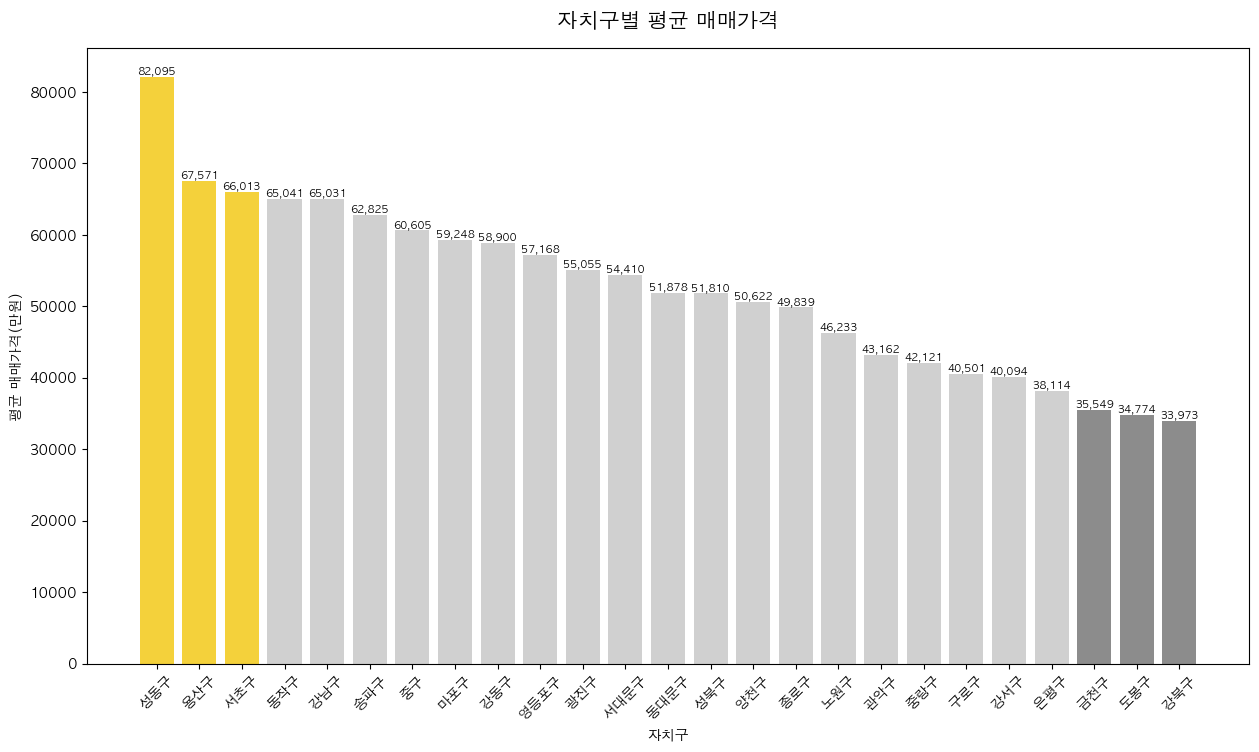

In [245]:
# 자치구별 평균 매매가격
avg_price_gu_sorted = avg_price_gu.sort_values("물건금액(만원)", ascending=False).reset_index(drop = True)


# 처음 3개 마지막 3개 그래프 강조
colors = []
for i in range(len(avg_price_gu_sorted)):
    if i < 3:
        colors.append("#F4D13B")
    elif i >= len(avg_price_gu_sorted) - 3:
        colors.append("#8C8C8C")
    else:
        colors.append("#D0D0D0")

# 자치구별 평균 매매가격 바 그래프
plt.figure(figsize=(15, 8))
plt.bar(avg_price_gu_sorted["자치구명"], avg_price_gu_sorted["물건금액(만원)"], color=colors)

plt.title("자치구별 평균 매매가격", fontsize = 15, fontweight = "bold", pad = 15)
plt.xlabel("자치구")
plt.ylabel("평균 매매가격(만원)")
plt.xticks(rotation=45)

# 표기
for i, v in enumerate(avg_price_gu_sorted["물건금액(만원)"]):
    plt.text(i,
             v,
             f"{v:,.0f}",
             ha='center',
             va='bottom',
             fontsize = 7.5)
plt.show()

In [246]:
# 자치구별 평균 평당 가격
gu_avg_py = df_all.groupby("자치구명")["평당가격"].mean().reset_index()
gu_avg_py["평당가격"] = gu_avg_py["평당가격"].round(2)
gu_avg_py = gu_avg_py.sort_values("평당가격", ascending=False).reset_index()

# print(gu_avg_py)

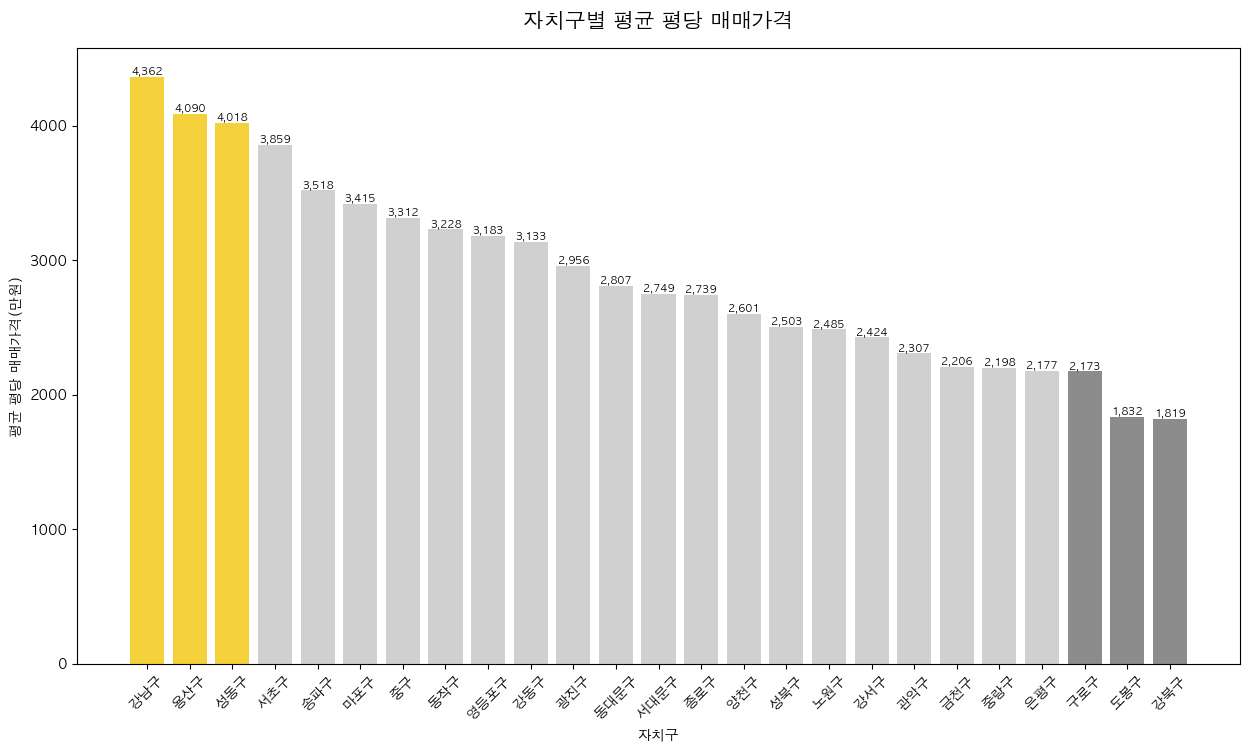

In [247]:
# 자치구별 평당 평균 매매가격
gu_avg_py_g = gu_avg_py.sort_values("평당가격", ascending = False).reset_index(drop = True)

# 처음 3개 마지막 3개 그래프 강조
colors = []
for i in range(len(gu_avg_py_g)):
    if i < 3:
        colors.append("#F4D13B")
    elif i >= len(gu_avg_py_g) - 3:
        colors.append("#8C8C8C")
    else:
        colors.append("#D0D0D0")

# 자치구별 평균 평당 매매가격 그래프
plt.figure(figsize = (15, 8))

plt.bar(gu_avg_py_g["자치구명"], gu_avg_py_g["평당가격"], color = colors)

plt.title("자치구별 평균 평당 매매가격", fontsize = 15, fontweight = "bold", pad = 15)
plt.xlabel("자치구")
plt.ylabel("평균 평당 매매가격(만원)")
plt.xticks(rotation=45)

# 표기
for i, v in enumerate(gu_avg_py_g["평당가격"]):
    plt.text(i,
             v,
             f"{v:,.0f}",
             ha='center',
             va='bottom',
             fontsize = 7.5)

plt.show()

In [248]:
# 나중에 계산하기 편하게 평당 가격을 연도별,자치구별로 한번에 볼수 있는 테이블을 만듬

price_diff_gu_year = df_all.pivot_table(index = "자치구명", columns = "접수연도", values = "평당가격", aggfunc = "mean")
price_diff_gu_year = price_diff_gu_year.reset_index()

years = sorted(df_all["접수연도"].unique())

# print(price_diff_gu_year)

In [249]:
# 각 연도별 평당 가격 상승률 계산

# 데이터 복사본 만들어서 거기다 계산하기
gu_growth_yearly_diff = price_diff_gu_year.copy()

for i in range(1, len(years)):
    pre_y = years[i-1]
    cur_y = years[i]
    col_name = f"{pre_y}->{cur_y} 상승률(%)"
    
    gu_growth_yearly_diff[col_name] = ((gu_growth_yearly_diff[cur_y] - gu_growth_yearly_diff[pre_y]) / gu_growth_yearly_diff[pre_y] * 100)

# gu_growth_yearly_diff

In [250]:
# 각 자치구별 평균 상승률 계산 

# 위에 만든 테이블에서 상승률 컬럼들만 골라내기
growth_cols = [c for c in gu_growth_yearly_diff.columns if "상승률(%)" in str(c)]

# 필요한 컬럼들이 맞게 나왔는지 확인
# print("상승률(%)컬럼들:", growth_cols)

# 자치구별 평균 상승률 (성장성)
gu_growth_yearly_diff["평균상승률(%)"] = gu_growth_yearly_diff[growth_cols].mean(axis=1).round(4)

# 자치구별 상승률 변동성 -> 표준편차 -> 표준편차가 클수록 어떤 해는 크게 오르고 어떤해는 크게 내려감
# 표준편차가 작을수록 각겨이 안정적으로 상승또는 하락
gu_growth_yearly_diff["상승률변동성"] = gu_growth_yearly_diff[growth_cols].std(axis=1).round(4)

# print(gu_growth_yearly_diff[["자치구명", "평균상승률(%)", "상승률변동성"]])

In [251]:
# 상대적 평가 -> 자치구 평균 평당 가격 vs 서울 전체 평균 평당 가격 
# 인사이트: 가격 메리트를 확인 할수 있다. 각겨, 상승률이랑 같이 보았을때 어느정도의 투자 가치를 판별이 가능하다  

# 제일 최근 년도인 2024도를 지정  
latest_year = years[6]

# 자치구별 현재 평균 가격
gu_growth_yearly_diff["현재평당가격"] = gu_growth_yearly_diff[latest_year]

# 서울 전체 평균 가격
seoul_total_avg_price = gu_growth_yearly_diff["현재평당가격"].mean()
# print(seoul_total_avg_price) # 서울 평균 평당 가격 -> 3631.77

# 자치구 평균 가격 vs 서울 전체 평균 가격
# 만약 1보다 크다 -> 비싸다 1보다 작다 -> 싸다 그리고 만약의 값이 1.39(강남구) -> 서울평균 가격보다 39.56%더 비싸다를 의미한다 
gu_growth_yearly_diff["상대적가격비율"] = (gu_growth_yearly_diff["현재평당가격"] / seoul_total_avg_price)

# rint(gu_growth_yearly_diff[["자치구명", "현재평당가격", "상대적가격비율"]])

In [252]:
# 각 요소들의 z-score 구하기 -> 이 세가지 요소가 투자 의사결정을 결정하는데 중요한 요소들이므로 이3가지 요소들의 z-score를 더해서 최종 투자가치를 판단함
# 데이터 안전성을 위한 테이블 카피
gu_z_score = gu_growth_yearly_diff.copy()

# z-score을 구하는데 필요한거 -> 평균, 그값, std(standard deviation) -> 값은 위에서 구했고 평균이랑 std구하는 작업

# 가격 상승률 (평균이랑 std) -> 가격이 얼마나 올랐는지 의미함 
mean_growth = gu_z_score["평균상승률(%)"].mean()
std_growth = gu_z_score["평균상승률(%)"].std()

# 평당 가격 -> 가격이 서울전체 평균보다 얼마나 비싸거나 싼지
mean_price_py = gu_z_score["현재평당가격"].mean()
std_price_py = gu_z_score["현재평당가격"].std()

# 상승률의 변동성 -> 가격의 변동이 큰지(안전성)을 의미함 
mean_vol = gu_z_score["상승률변동성"].mean()
std_vol  = gu_z_score["상승률변동성"].std()

# 위 3가지의 z-score 구하기 
gu_z_score["성장성_Z"] = (gu_z_score["평균상승률(%)"] - mean_growth) / std_growth
gu_z_score["가격_Z"] = (gu_z_score["현재평당가격"] - mean_price_py) / std_price_py
gu_z_score["변동성_Z"] = (gu_z_score["상승률변동성"] - mean_vol) / std_vol

# 여기서 가격이랑 변동성은 낮은게 더 좋으므로 (-) 를 앞에 붙여준다 
gu_z_score["성장성점수"] = gu_z_score["성장성_Z"].round(4)
gu_z_score["가격점수"] = -gu_z_score["가격_Z"].round(4)
gu_z_score["변동성점수"] = -gu_z_score["변동성_Z"].round(4)

In [253]:
# 최종 점수 안전형/중립형/위험형

# 각 투자 유형의 특징에 맞게 가중치를 임의로 부여함 (가중치 총합은 3으로 동일) 
#안전성 ->  성장성(0.5) + 가격(1) + 변동성(1.5 가장 중요함)
#중립형 ->  성장성(1) + 가격(1) + 변동성(1)
#공격형 ->  성장성(1.5 가장 중요) + 가격(0.7) + 변동성(0.3)

# 안전형
gu_z_score["안전형점수 구"] = (0.5 * gu_z_score["성장성점수"]) + gu_z_score["가격점수"] + (1.5 * gu_z_score["변동성점수"])

# 중립형
gu_z_score["중립형점수 구"] = gu_z_score["성장성점수"] + gu_z_score["가격점수"] + gu_z_score["변동성점수"]

# 공격형
gu_z_score["공격형점수 구"] = (1.5 * gu_z_score["성장성점수"]) + (1 * gu_z_score["가격점수"]) + (0.5 * gu_z_score["변동성점수"])

# 안전형
safe_rank_gu = gu_z_score.sort_values("안전형점수 구", ascending=False).reset_index(drop=True)

# 중립형
neutral_rank_gu = gu_z_score.sort_values("중립형점수 구", ascending=False).reset_index(drop=True)

# 공격형 
aggr_rank_gu = gu_z_score.sort_values("공격형점수 구", ascending=False).reset_index(drop=True)


In [254]:
# 결과 확인
print(safe_rank_gu[["자치구명","안전형점수 구","성장성점수","가격점수","변동성점수"]].head(3))

print(neutral_rank_gu[["자치구명","중립형점수 구","성장성점수","가격점수","변동성점수"]].head(3))

print(aggr_rank_gu[["자치구명","공격형점수 구","성장성점수","가격점수","변동성점수"]].head(3))

접수연도 자치구명  안전형점수 구   성장성점수    가격점수   변동성점수
0     중랑구  3.01900  1.0419  0.8662  1.0879
1     도봉구  2.49390 -1.0852  1.6241  0.9416
2     관악구  2.48295 -0.8162  0.9571  1.2893
접수연도 자치구명  중립형점수 구   성장성점수    가격점수   변동성점수
0     중랑구   2.9960  1.0419  0.8662  1.0879
1     금천구   2.7901  1.2435  0.9270  0.6196
2     은평구   1.8658  0.1905  0.9052  0.7701
접수연도  자치구명  공격형점수 구   성장성점수    가격점수   변동성점수
0      금천구  3.10205  1.2435  0.9270  0.6196
1      중랑구  2.97300  1.0419  0.8662  1.0879
2     서대문구  1.77970  1.0217 -0.0049  0.5041


In [255]:
# 안전형 투자자가 투자를 할 3구 
top3_safe_gu = safe_rank_gu.head(3)[["자치구명", "안전형점수 구"]]
#print(top3_safe_gu)

# 안전형 투자자가 투자할 3구 (계산용)
top3_safe_gu_list = top3_safe_gu["자치구명"].tolist()
# print(top3_safe_gu)

In [256]:
# 3구에 속한 건물용도 확인하기, 데이터 크기 확인하기 (안전형)

df_safe_top_gu = df_all[df_all["자치구명"].isin(top3_safe_gu_list)].copy()
# print(df_safe_top_gu.shape)
# print(df_safe_top_gu["건물용도"].value_counts())

# 안전형 투자자를 위한 자치구별 + 건물용도별 연도별 평균가격을 테이블로 만듬
safe_gu_safe_price = df_safe_top_gu.pivot_table( index = ["자치구명", "건물용도"], columns = "접수연도", values = "평당가격", aggfunc = "mean").reset_index()
print(safe_gu_safe_price)

접수연도 자치구명   건물용도         2018         2019         2020         2021  \
0     관악구  단독다가구  1663.655908  1786.858786  1986.211078  1995.319971   
1     관악구    아파트  2108.614987  2484.796027  2837.816644  3592.815504   
2     관악구  연립다세대  1646.589356  1757.634865  1869.676455  2034.482574   
3     관악구   오피스텔  2013.970979  2133.798207  2167.712075  2366.032548   
4     도봉구  단독다가구  1158.207780  1382.853036  1376.297485  1458.841941   
5     도봉구    아파트  1661.983712  1925.305375  2205.173609  2955.282021   
6     도봉구  연립다세대  1135.527567  1239.302127  1298.560417  1490.457648   
7     도봉구   오피스텔  1412.726222  1625.181199  1699.366615  2279.771182   
8     중랑구  단독다가구  1341.853572  1470.318130  1493.815832  1697.353049   
9     중랑구    아파트  1776.742318  2167.951853  2471.336904  3183.522645   
10    중랑구  연립다세대  1571.201675  1673.232820  1886.685316  2149.317961   
11    중랑구   오피스텔  1459.853024  1934.510706  1783.625722  1864.066956   

접수연도         2022         2023         2024  
0     2021.133989

In [257]:
safe_gu_growth = safe_gu_safe_price.copy()

# 연도마다 건물용도별 평당가격 상승률 (안전형)
for i in range(1, len(years)):
    pre_y = years[i-1]
    cur_y = years[i]
    col_name = f"{pre_y}->{cur_y} 상승률(%)"

    safe_gu_growth[col_name] = ((safe_gu_growth[cur_y] - safe_gu_growth[pre_y]) / safe_gu_growth[pre_y] * 100)

# 데이터에서 상승률만 들어간 컬럼만 추출
growth_cols_use_safe = [c for c in safe_gu_growth.columns if "상승률(%)" in str(c)]

# 평균 상승률하고 변동성 구하기
safe_gu_growth["평균상승률(%)"] = safe_gu_growth[growth_cols_use_safe].mean(axis=1)
safe_gu_growth["상승률변동성"] = safe_gu_growth[growth_cols_use_safe].std(axis=1)

safe_gu_growth["현재평당가격"] = safe_gu_growth[years[6]]

print(safe_gu_growth[["자치구명", "건물용도", "평균상승률(%)", "상승률변동성", "현재평당가격"]])

접수연도 자치구명   건물용도   평균상승률(%)     상승률변동성       현재평당가격
0     관악구  단독다가구   3.580054   5.789078  2038.440905
1     관악구    아파트   8.934530  13.546129  3386.770523
2     관악구  연립다세대   4.697276   7.880702  2137.849486
3     관악구   오피스텔   3.623544  12.268139  2404.437669
4     도봉구  단독다가구   2.692204  13.700384  1298.623517
5     도봉구    아파트   8.800228  16.324929  2606.213108
6     도봉구  연립다세대   5.610283   8.560731  1548.462954
7     도봉구   오피스텔   2.733808  19.618700  1521.020617
8     중랑구  단독다가구   1.071897  10.976834  1387.742190
9     중랑구    아파트  10.046343  13.982120  3030.369296
10    중랑구  연립다세대   9.871810   6.981266  2736.525227
11    중랑구   오피스텔  13.268676  20.782882  2836.604392


In [258]:
# 데이터 복사 만들기
safe_gu_z_score = safe_gu_growth.copy()

# 각 지표의 전체 평균 및 standard deviation 구하기
mean_growth_s = safe_gu_z_score["평균상승률(%)"].mean()
std_growth_s = safe_gu_z_score["평균상승률(%)"].std()

mean_price_s = safe_gu_z_score["현재평당가격"].mean()
std_price_s = safe_gu_z_score["현재평당가격"].std()

mean_vol_s = safe_gu_z_score["상승률변동성"].mean()
std_vol_s = safe_gu_z_score["상승률변동성"].std()

# z-score 구하기
safe_gu_z_score["성장성s_z_score"] = (safe_gu_z_score["평균상승률(%)"] - mean_growth_s) / std_growth_s
safe_gu_z_score["가격s_z_score"] = (safe_gu_z_score["현재평당가격"] - mean_price_s) / std_price_s
safe_gu_z_score["변동성s_z_score"] = (safe_gu_z_score["상승률변동성"] - mean_vol_s) / std_vol_s

# - 로 바꾸기
safe_gu_z_score["s성장성_z_score"] = safe_gu_z_score["성장성s_z_score"]        
safe_gu_z_score["s가격_z_score"] = -safe_gu_z_score["가격s_z_score"]
safe_gu_z_score["s변동성_z_score"] = -safe_gu_z_score["변동성s_z_score"]


# 구한 z-score 다 더하기
safe_gu_z_score["안전형투자건물점수"] = ((0.5 * safe_gu_z_score["s성장성_z_score"]) + safe_gu_z_score["s가격_z_score"] + (1.5 * safe_gu_z_score["s변동성_z_score"]))

# 최종 점수 순서대로 나열 
safe_gu_rank = safe_gu_z_score.sort_values("안전형투자건물점수", ascending=False).reset_index(drop=True)

print(safe_gu_rank[["자치구명", "건물용도", "안전형투자건물점수", "평균상승률(%)", "상승률변동성", "현재평당가격", "s성장성_z_score", "s가격_z_score", "s변동성_z_score"]])

접수연도 자치구명   건물용도  안전형투자건물점수   평균상승률(%)     상승률변동성       현재평당가격  s성장성_z_score  \
0     도봉구  연립다세대   2.155468   5.610283   8.560731  1548.462954     -0.166646   
1     관악구  단독다가구   2.053111   3.580054   5.789078  2038.440905     -0.700341   
2     중랑구  연립다세대   1.507586   9.871810   6.981266  2736.525227      0.953600   
3     관악구  연립다세대   1.403827   4.697276   7.880702  2137.849486     -0.406652   
4     중랑구  단독다가구   1.033994   1.071897  10.976834  1387.742190     -1.359671   
5     도봉구  단독다가구   0.523351   2.692204  13.700384  1298.623517     -0.933734   
6     관악구   오피스텔  -0.490449   3.623544  12.268139  2404.437669     -0.688909   
7     중랑구    아파트  -1.078494  10.046343  13.982120  3030.369296      0.999480   
8     도봉구    아파트  -1.367012   8.800228  16.324929  2606.213108      0.671909   
9     관악구    아파트  -1.598834   8.934530  13.546129  3386.770523      0.707213   
10    도봉구   오피스텔  -1.639515   2.733808  19.618700  1521.020617     -0.922798   
11    중랑구   오피스텔  -2.503034  13.268676  

In [259]:
# 중립형
# 위에 코드에 중립형 데이터를 넣고 똑같이 돌리기

top3_neutral_gu = neutral_rank_gu.head(3)[["자치구명", "중립형점수 구"]]
# print(top3_neutral_gu)
top3_neutral_gu_list = top3_neutral_gu["자치구명"].tolist()
# print(top3_neutral_gu)

df_neutral_top_gu = df_all[df_all["자치구명"].isin(top3_neutral_gu_list)].copy()
# print(df_neutral_top_gu.shape)
# print(df_neutral_top_gu["건물용도"].value_counts())

neutral_gu_safe_price = df_neutral_top_gu.pivot_table(index = ["자치구명", "건물용도"],  columns = "접수연도",  values = "평당가격",  aggfunc = "mean").reset_index()
# print(neutral_gu_safe_price)

neutral_gu_growth = neutral_gu_safe_price.copy()

for i in range(1, len(years)):
    pre_y = years[i-1]
    cur_y = years[i]
    col_name = f"{pre_y}->{cur_y} 상승률(%)"

    neutral_gu_growth[col_name] = ((neutral_gu_growth[cur_y] - neutral_gu_growth[pre_y]) / neutral_gu_growth[pre_y] * 100)

growth_cols_use_neutral = [c for c in neutral_gu_growth.columns if "상승률(%)" in str(c)]   

neutral_gu_growth["평균상승률(%)"] = neutral_gu_growth[growth_cols_use_neutral].mean(axis=1)
neutral_gu_growth["상승률변동성"] = neutral_gu_growth[growth_cols_use_neutral].std(axis=1)

neutral_gu_growth["현재평당가격"] = neutral_gu_growth[years[6]]
# print(neutral_gu_growth[["자치구명", "건물용도", "평균상승률(%)", "상승률변동성", "현재평당가격"]])

neutral_gu_z_score = neutral_gu_growth.copy()

mean_growth_n = neutral_gu_z_score["평균상승률(%)"].mean()
std_growth_n = neutral_gu_z_score["평균상승률(%)"].std()

mean_price_n = neutral_gu_z_score["현재평당가격"].mean()
std_price_n = neutral_gu_z_score["현재평당가격"].std()

mean_vol_n = neutral_gu_z_score["상승률변동성"].mean()
std_vol_n = neutral_gu_z_score["상승률변동성"].std()

neutral_gu_z_score["성장성n_z_score"] = (neutral_gu_z_score["평균상승률(%)"] - mean_growth_n) / std_growth_n
neutral_gu_z_score["가격n_z_score"]   = (neutral_gu_z_score["현재평당가격"] - mean_price_n) / std_price_n
neutral_gu_z_score["변동성n_z_score"] = (neutral_gu_z_score["상승률변동성"] - mean_vol_n) / std_vol_n

neutral_gu_z_score["n성장성_z_score"] = neutral_gu_z_score["성장성n_z_score"]
neutral_gu_z_score["n가격_z_score"]   = -neutral_gu_z_score["가격n_z_score"]
neutral_gu_z_score["n변동성_z_score"] = -neutral_gu_z_score["변동성n_z_score"]

neutral_gu_z_score["중립형투자건물점수"] = (neutral_gu_z_score["n성장성_z_score"] + neutral_gu_z_score["n가격_z_score"] + neutral_gu_z_score["n변동성_z_score"])

neutral_gu_rank = neutral_gu_z_score.sort_values("중립형투자건물점수", ascending=False).reset_index(drop=True)

print(neutral_gu_rank[["자치구명", "건물용도", "중립형투자건물점수", "평균상승률(%)", "상승률변동성", "현재평당가격", "n성장성_z_score", "n가격_z_score", "n변동성_z_score"]])

접수연도 자치구명   건물용도  중립형투자건물점수   평균상승률(%)     상승률변동성       현재평당가격  n성장성_z_score  \
0     은평구  연립다세대   1.521885   5.849286   5.398575  2137.855680     -0.279330   
1     금천구  연립다세대   1.268042   6.594257   6.538460  2246.192456     -0.115465   
2     중랑구  연립다세대   1.196390   9.871810   6.981266  2736.525227      0.605472   
3     금천구  단독다가구   0.795862   2.591057   9.608156  1447.582388     -0.996016   
4     은평구  단독다가구   0.239786   2.496255   8.526395  2007.290737     -1.016869   
5     중랑구  단독다가구   0.227222   1.071897  10.976834  1387.742190     -1.330174   
6     금천구   오피스텔  -0.491840  11.915168  13.296936  3211.138327      1.054933   
7     은평구    아파트  -0.658346  10.353970   9.804060  3663.598993      0.711529   
8     금천구    아파트  -0.774687  10.952737  14.847470  3005.038638      0.843235   
9     중랑구    아파트  -0.808225  10.046343  13.982120  3030.369296      0.643863   
10    은평구   오피스텔  -1.105902   0.418796  12.202335  2030.732744     -1.473831   
11    중랑구   오피스텔  -1.410187  13.268676  

In [260]:
# 공격형 투자자

top3_aggr_gu = aggr_rank_gu.head(3)[["자치구명", "공격형점수 구"]]
# print(top3_aggr_gu)
top3_aggr_gu_list = top3_aggr_gu["자치구명"].tolist()
# print(top3_aggr_gu)

df_aggr_top_gu = df_all[df_all["자치구명"].isin(top3_aggr_gu_list)].copy()
# print(df_aggr_top_gu.shape)
# print(df_aggr_top_gu["건물용도"].value_counts())

aggr_gu_safe_price = df_aggr_top_gu.pivot_table(index = ["자치구명", "건물용도"], columns = "접수연도", values = "평당가격", aggfunc = "mean").reset_index()
# print(aggr_gu_safe_price)

aggr_gu_growth = aggr_gu_safe_price.copy()

for i in range(1, len(years)):
    pre_y = years[i-1]
    cur_y = years[i]
    col_name = f"{pre_y}->{cur_y} 상승률(%)"

    aggr_gu_growth[col_name] = ((aggr_gu_growth[cur_y] - aggr_gu_growth[pre_y]) / aggr_gu_growth[pre_y] * 100)

growth_cols_use_aggr = [c for c in aggr_gu_growth.columns if "상승률(%)" in str(c)]

aggr_gu_growth["평균상승률(%)"] = aggr_gu_growth[growth_cols_use_aggr].mean(axis=1)
aggr_gu_growth["상승률변동성"] = aggr_gu_growth[growth_cols_use_aggr].std(axis=1)

aggr_gu_growth["현재평당가격"] = aggr_gu_growth[years[6]]

# print(aggr_gu_growth[["자치구명", "건물용도", "평균상승률(%)", "상승률변동성", "현재평당가격"]])

aggr_gu_z_score = aggr_gu_growth.copy()

mean_growth_a = aggr_gu_z_score["평균상승률(%)"].mean()
std_growth_a = aggr_gu_z_score["평균상승률(%)"].std()

mean_price_a = aggr_gu_z_score["현재평당가격"].mean()
std_price_a = aggr_gu_z_score["현재평당가격"].std()

mean_vol_a = aggr_gu_z_score["상승률변동성"].mean()
std_vol_a = aggr_gu_z_score["상승률변동성"].std()

aggr_gu_z_score["성장성a_z_score"] = (aggr_gu_z_score["평균상승률(%)"] - mean_growth_a) / std_growth_a
aggr_gu_z_score["가격a_z_score"]   = (aggr_gu_z_score["현재평당가격"] - mean_price_a) / std_price_a
aggr_gu_z_score["변동성a_z_score"] = (aggr_gu_z_score["상승률변동성"] - mean_vol_a) / std_vol_a

aggr_gu_z_score["a성장성_z_score"] = aggr_gu_z_score["성장성a_z_score"]
aggr_gu_z_score["a가격_z_score"]   = -aggr_gu_z_score["가격a_z_score"]
aggr_gu_z_score["a변동성_z_score"] = -aggr_gu_z_score["변동성a_z_score"]

aggr_gu_z_score["공격형투자건물점수"] = ((1.5 * aggr_gu_z_score["a성장성_z_score"]) + (aggr_gu_z_score["a가격_z_score"]) + (0.5 * aggr_gu_z_score["a변동성_z_score"]))

aggr_gu_rank = aggr_gu_z_score.sort_values("공격형투자건물점수", ascending = False).reset_index(drop = True)

print(aggr_gu_rank[["자치구명", "건물용도", "공격형투자건물점수", "평균상승률(%)", "상승률변동성", "현재평당가격", "a성장성_z_score", "a가격_z_score", "a변동성_z_score"]])


접수연도  자치구명   건물용도  공격형투자건물점수   평균상승률(%)     상승률변동성       현재평당가격  a성장성_z_score  \
0      중랑구  연립다세대   1.211246   9.871810   6.981266  2736.525227      0.463995   
1      중랑구   오피스텔   0.821255  13.268676  20.782882  2836.604392      1.374585   
2      금천구   오피스텔   0.710036  11.915168  13.296936  3211.138327      1.011753   
3      금천구  연립다세대   0.539638   6.594257   6.538460  2246.192456     -0.414612   
4      금천구    아파트   0.389008  10.952737  14.847470  3005.038638      0.753756   
5      중랑구    아파트   0.096359  10.046343  13.982120  3030.369296      0.510782   
6     서대문구  연립다세대  -0.335372   5.244283   9.328888  2247.582886     -0.776497   
7     서대문구   오피스텔  -0.365163   8.603621   6.231014  3690.451667      0.124034   
8     서대문구  단독다가구  -0.457779   7.114339   8.505488  3050.043640     -0.275195   
9      금천구  단독다가구  -0.466411   2.591057   9.608156  1447.582388     -1.487741   
10    서대문구    아파트  -0.975916  10.416910  12.331237  4200.196253      0.610119   
11     중랑구  단독다가구  -1.166901

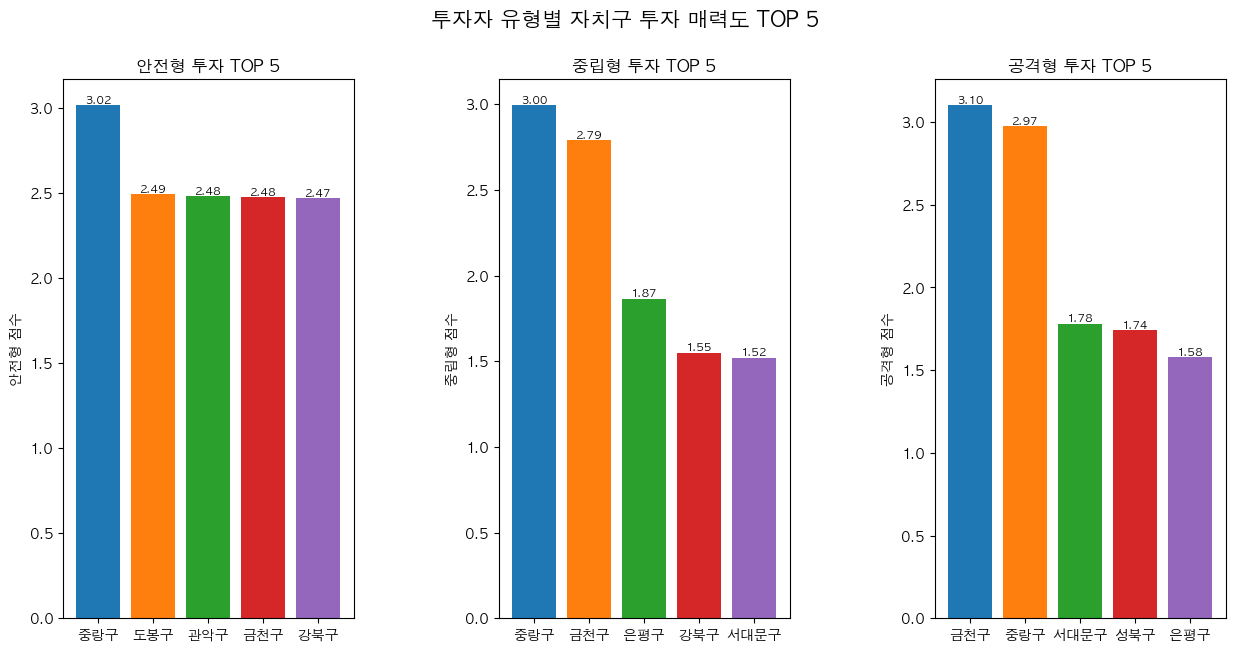

In [261]:
# 투자 성향(안전형,중립형,공격형)에 따라 투자 유망 지역이 어떻게 달라지는지에 대한 시각화

safe_top5    = safe_rank_gu.head(5)[["자치구명", "안전형점수 구"]]
neutral_top5 = neutral_rank_gu.head(5)[["자치구명", "중립형점수 구"]]
aggr_top5    = aggr_rank_gu.head(5)[["자치구명", "공격형점수 구"]]

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

fig, axes = plt.subplots(1, 3, figsize = (15, 7))
fig.suptitle("투자자 유형별 자치구 투자 매력도 TOP 5", fontsize = 15)
fig.subplots_adjust(wspace = 0.5)

# 안전형 투자자 
x = axes[0]
x_idx = range(len(safe_top5))

x.bar(x_idx, safe_top5["안전형점수 구"], color = colors[:len(safe_top5)])

x.set_title("안전형 투자 TOP 5")
x.set_xticks(x_idx)
x.set_xticklabels(safe_top5["자치구명"])
x.set_ylabel("안전형 점수")

# 막대 위에 점수 표시
for i, v in enumerate(safe_top5["안전형점수 구"]):
    x.text(i, v, f"{v:.2f}", ha = 'center', va = 'bottom', fontsize = 8)

# 중립형 투자자
x1 = axes[1]
x_idx = range(len(neutral_top5))

x1.bar(x_idx, neutral_top5["중립형점수 구"], color = colors[:len(neutral_top5)])

x1.set_title("중립형 투자 TOP 5")
x1.set_xticks(x_idx)
x1.set_xticklabels(neutral_top5["자치구명"])
x1.set_ylabel("중립형 점수")

for i, v in enumerate(neutral_top5["중립형점수 구"]):
    x1.text(i, v, f"{v:.2f}", ha='center', va='bottom', fontsize = 8)

# 공격형 투자자
x2 = axes[2]
x_idx = range(len(aggr_top5))

x2.bar(x_idx, aggr_top5["공격형점수 구"], color=colors[:len(aggr_top5)])

x2.set_title("공격형 투자 TOP 5")
x2.set_xticks(x_idx)
x2.set_xticklabels(aggr_top5["자치구명"])
x2.set_ylabel("공격형 점수")

for i, v in enumerate(aggr_top5["공격형점수 구"]):
    x2.text(i, v, f"{v:.2f}", ha='center', va = 'bottom', fontsize = 8)

plt.show()

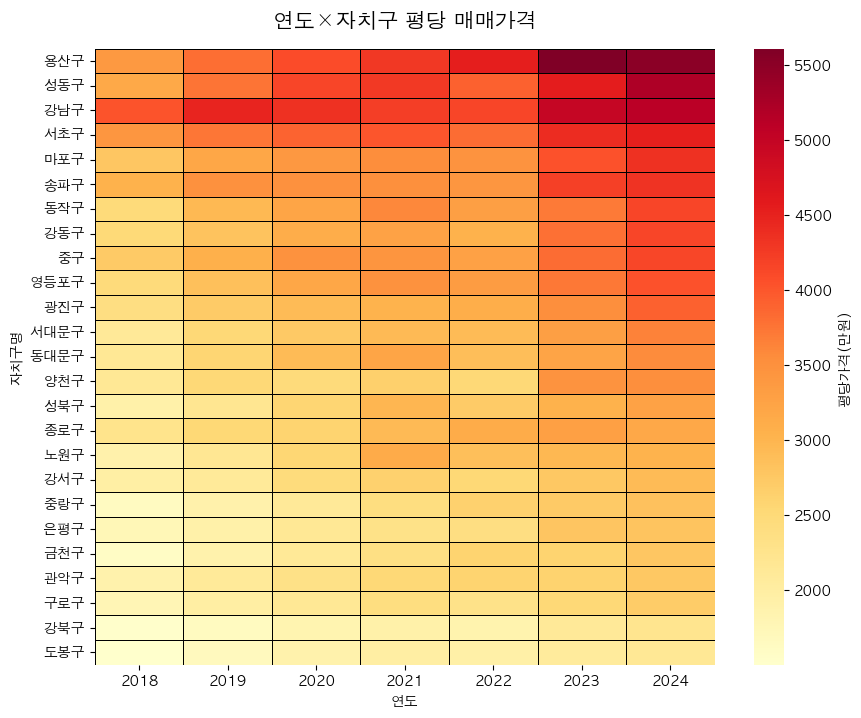

In [262]:
# 성장성/안전성
# 연도 x 자치구 평당가 heatmap 

latest_year = max(years)
df3_1 = price_diff_gu_year.copy()

df3_1 = df3_1.sort_values(latest_year, ascending = False)
df3_1 = df3_1.set_index("자치구명")[years]

plt.figure(figsize = (10, 8))

df3_1_heat = sns.heatmap(
    df3_1,
    cmap = "YlOrRd",
    linewidths = 0.5,     
    linecolor = "black",
    cbar_kws={"label": "평당가격(만원)"}  
)

plt.title("연도×자치구 평당 매매가격", pad = 16, fontsize = 15, fontweight = 'bold')
plt.xlabel("연도")
plt.ylabel("자치구명")

plt.show()

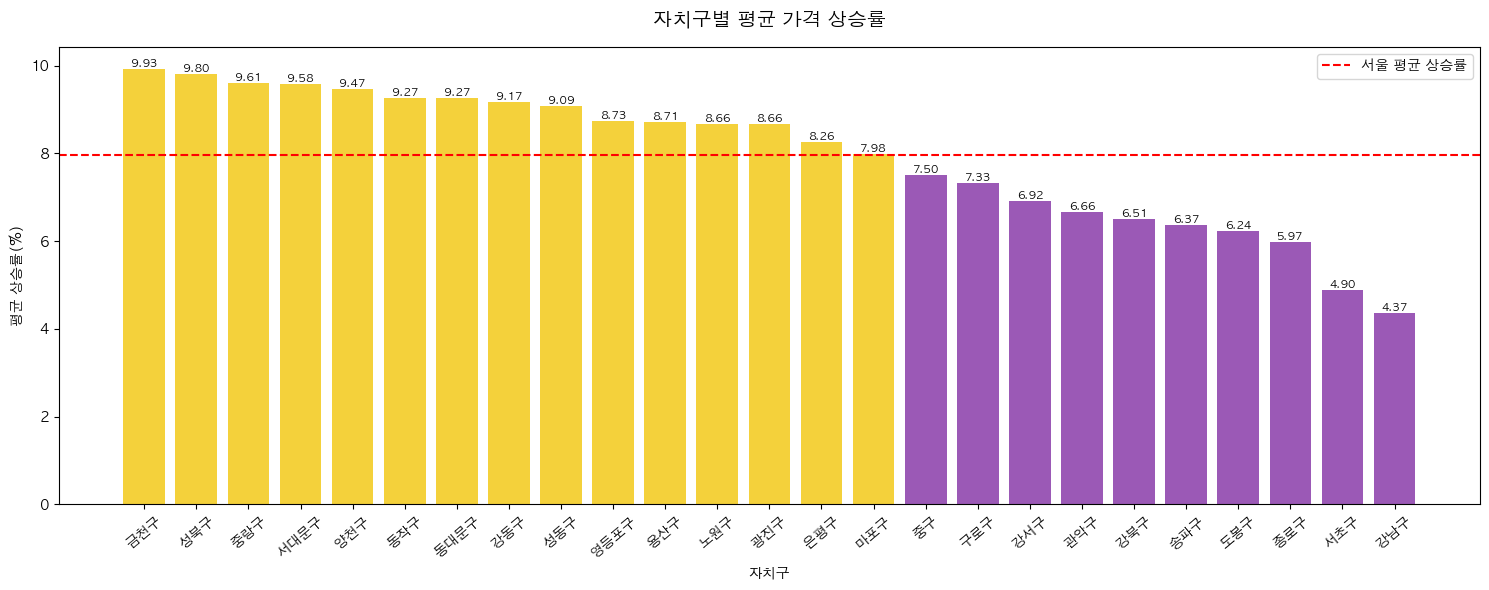

In [263]:
# 성장성/안전성
# 2. 자치구별 평균 상승률 Bar chart

df3_2 = gu_growth_yearly_diff[["자치구명", "평균상승률(%)"]].copy()
df3_2 = df3_2.sort_values("평균상승률(%)", ascending=False).reset_index(drop=True)

seoul_avg_growth = df3_2["평균상승률(%)"].mean()

colors = []
for g in df3_2["평균상승률(%)"]:
    if g >=  seoul_avg_growth:
        colors.append("#F4D13B")
    else:
        colors.append("#9b59b6")

plt.figure(figsize = (15,6))

plt.bar(range(len(df3_2)), df3_2["평균상승률(%)"], color = colors)
plt.xticks(range(len(df3_2)), df3_2["자치구명"], rotation = 40)

plt.title("자치구별 평균 가격 상승률", pad = 15, fontsize = 14, fontweight = "bold")
plt.xlabel("자치구")
plt.ylabel("평균 상승률(%)")

plt.axhline(y = seoul_avg_growth, color = 'red', linestyle = '--', linewidth = 1.5, label = '서울 평균 상승률')
plt.legend(loc="upper right")
plt.tight_layout()

for i, v in enumerate(df3_2["평균상승률(%)"]):
    plt.text(i, 
             v, 
             f"{v:.2f}",
             ha='center', 
             va='bottom',
             fontsize=8)
plt.show()

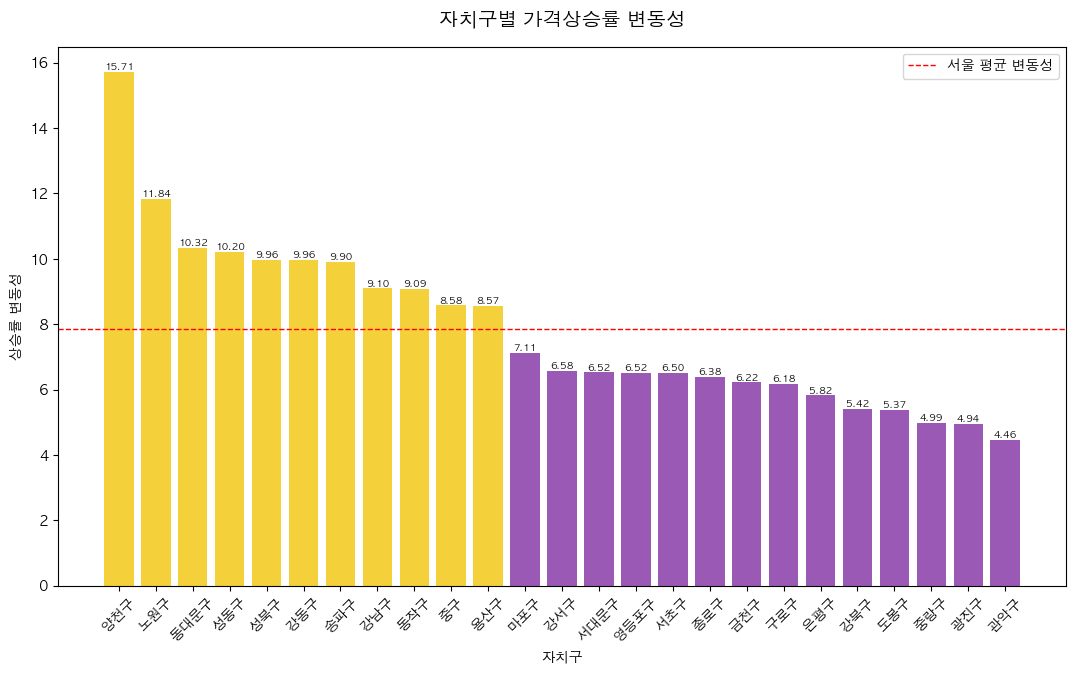

In [264]:
# 성장성/안전성
# 자치구별 상승률 변동성(표준편차) Bar chart

df3_3 = gu_growth_yearly_diff[["자치구명", "상승률변동성"]].copy()
df3_3 = df3_3.sort_values("상승률변동성", ascending = False).reset_index(drop=True)

seoul_avg_vol = df3_3["상승률변동성"].mean()

colors = []
for v in df3_3["상승률변동성"]:
    if v <= seoul_avg_vol:
        colors.append("#9b59b6") 
    else:
        colors.append("#F4D13B")

plt.figure(figsize = (13, 7))
plt.bar(range(len(df3_3)), df3_3["상승률변동성"], color=colors)
plt.xticks(range(len(df3_3)), df3_3["자치구명"], rotation=45)

plt.title("자치구별 가격상승률 변동성", fontsize = 14, fontweight = 'bold', pad = 15)
plt.xlabel("자치구")
plt.ylabel("상승률 변동성")

plt.axhline(seoul_avg_vol, color = 'red', linestyle = '--', linewidth = 1, label = '서울 평균 변동성')
plt.legend(loc="upper right")

for i, v in enumerate(df3_3["상승률변동성"]):
    plt.text(i, 
             v, 
             f"{v:.2f}",
             ha = 'center', 
             va = 'bottom',
             fontsize = 7)
plt.show()

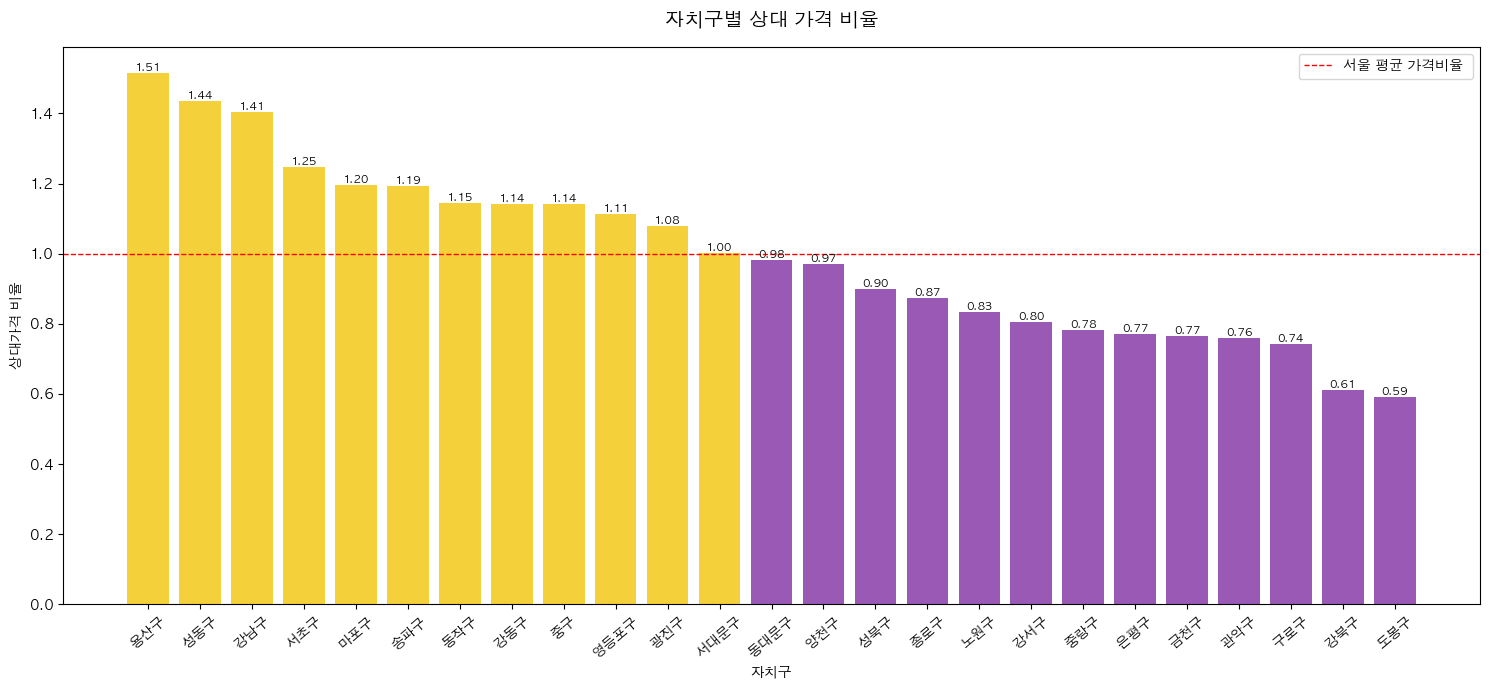

In [265]:
# 성장성/안전성
# 자치구 상대가격비율 Bar chart

df3_4 = gu_growth_yearly_diff[["자치구명", "상대적가격비율"]].copy()
df3_4 = df3_4.sort_values("상대적가격비율", ascending = False).reset_index(drop = True)

colors = []
for ratio in df3_4["상대적가격비율"]:
    if ratio > 1:
        colors.append("#F4D13B")
    else:
        colors.append("#9b59b6")

plt.figure(figsize = (15, 7))
plt.bar(range(len(df3_4)), df3_4["상대적가격비율"], color = colors)
plt.xticks(range(len(df3_4)), df3_4["자치구명"], rotation = 40)

plt.title("자치구별 상대 가격 비율", fontsize = 14, fontweight = 'bold', pad = 15)
plt.xlabel("자치구")
plt.ylabel("상대가격 비율")


plt.axhline(1, color = 'red', linestyle = '--', linewidth = 1, label = '서울 평균 가격비율 ')
plt.legend(loc = "upper right")
plt.tight_layout()

for i, v in enumerate(df3_4["상대적가격비율"]):
    plt.text(i, 
             v, 
             f"{v:.2f}",
             ha='center', 
             va='bottom',
             fontsize = 8)
plt.show()

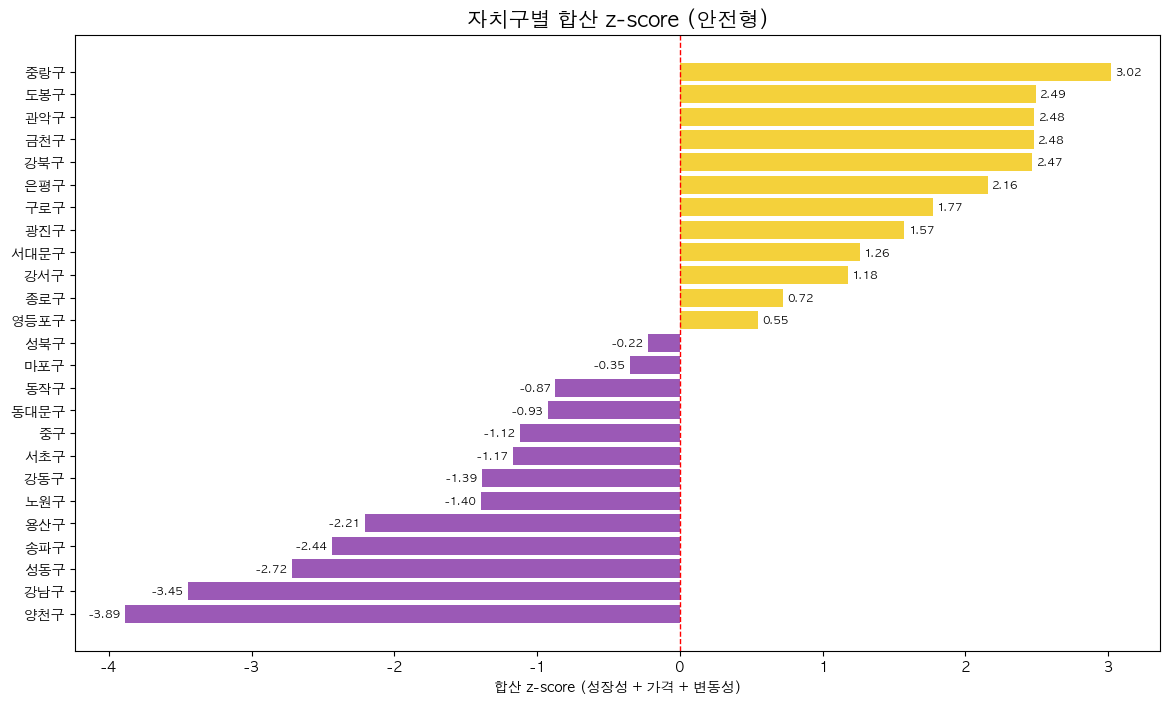

In [266]:
# 안전형 투자자가 선호하는 구 -> z-score 총합

df_safe = gu_z_score[["자치구명", "안전형점수 구"]].copy()

df_safe = df_safe.sort_values("안전형점수 구", ascending = True).reset_index(drop = True)

colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in df_safe["안전형점수 구"]]

plt.figure(figsize = (14, 8))

plt.barh(range(len(df_safe)), df_safe["안전형점수 구"], color = colors)
plt.yticks(range(len(df_safe)), df_safe["자치구명"])

plt.title("자치구별 합산 z-score (안전형)", fontsize = 15, fontweight = "bold")
plt.xlabel("합산 z-score (성장성 + 가격 + 변동성)")

plt.axvline(0, color = 'red', linestyle = '--', linewidth = 1)

for i, v in enumerate(df_safe["안전형점수 구"]):
    if v >= 0:
        x_pos = v + 0.03
        ha = "left"
    else:
        x_pos = v - 0.03
        ha = "right"
    plt.text(x_pos, i, f"{v:.2f}", va="center", ha=ha, fontsize=8)

plt.show()

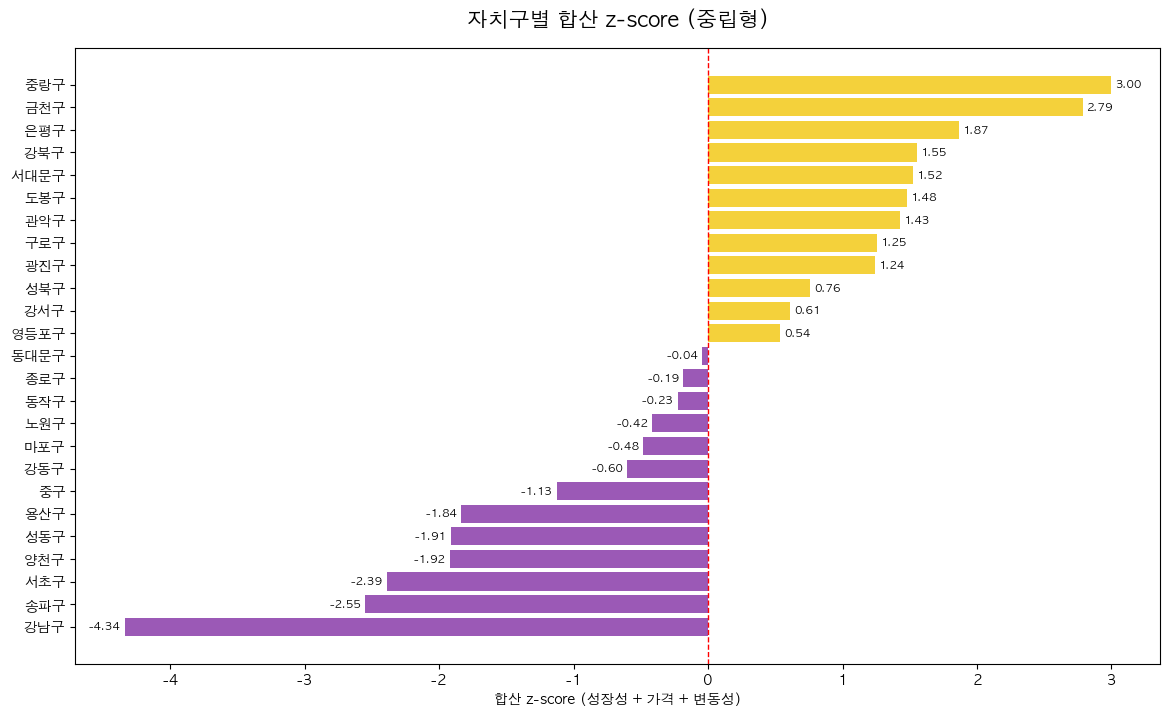

In [267]:
# 중립형 투자자들이 선호화는구 -> z-score 총합 

df_mid = gu_z_score[["자치구명", "중립형점수 구"]].copy()
df_mid = df_mid.sort_values("중립형점수 구").reset_index(drop=True)
colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in df_mid["중립형점수 구"]]

plt.figure(figsize = (14, 8))

plt.barh(range(len(df_mid)), df_mid["중립형점수 구"], color=colors)
plt.yticks(range(len(df_mid)), df_mid["자치구명"])

plt.title("자치구별 합산 z-score (중립형)", fontsize = 15, fontweight = "bold", pad = 15)
plt.xlabel("합산 z-score (성장성 + 가격 + 변동성)")

plt.axvline(0, color='red', linestyle = '--', linewidth = 1)

for i, v in enumerate(df_mid["중립형점수 구"]):
    if v >= 0:
        x_pos = v + 0.03
        ha = "left"
    else:
        x_pos = v - 0.03
        ha = "right"
    plt.text(x_pos, i, f"{v:.2f}", va="center", ha=ha, fontsize = 8)

plt.show()

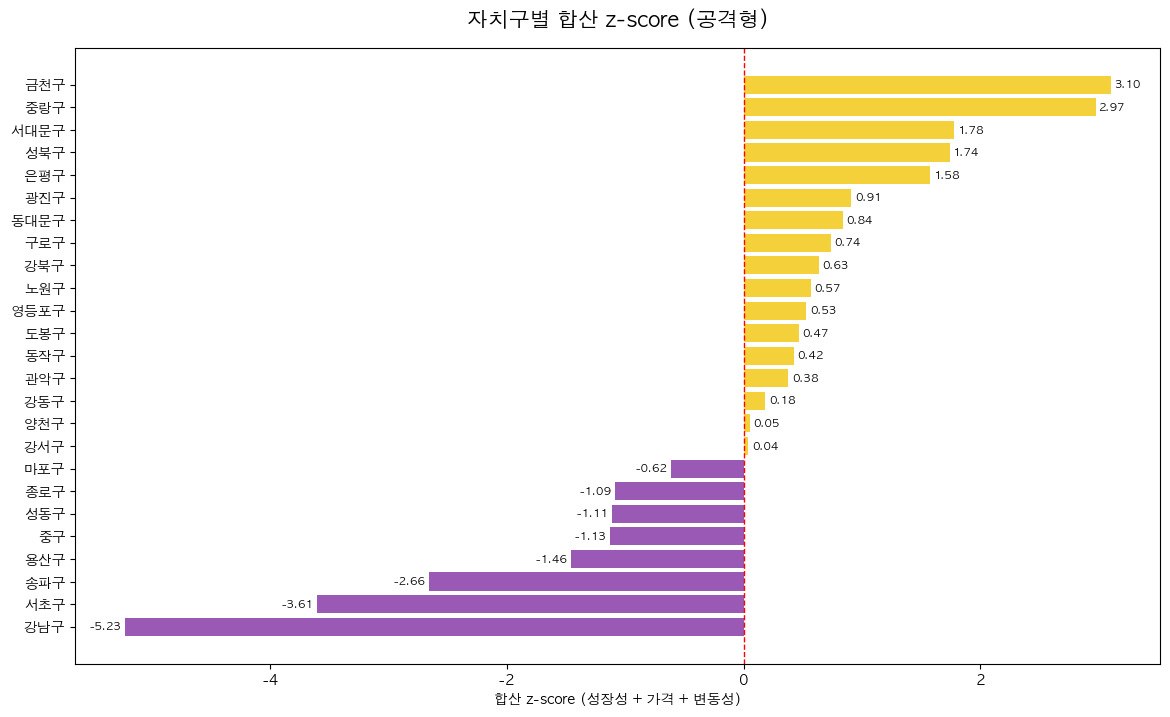

In [268]:
# 공격형 투자자들이 선호화는구 -> z-score 총합 

df_aggr = gu_z_score[["자치구명", "공격형점수 구"]].copy()
df_aggr = df_aggr.sort_values("공격형점수 구").reset_index(drop = True)
colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in df_aggr["공격형점수 구"]]

plt.figure(figsize = (14, 8))

plt.barh(range(len(df_aggr)), df_aggr["공격형점수 구"], color = colors)
plt.yticks(range(len(df_aggr)), df_aggr["자치구명"])

plt.title("자치구별 합산 z-score (공격형)", fontsize = 15, fontweight = "bold", pad = 15)
plt.xlabel("합산 z-score (성장성 + 가격 + 변동성)")

plt.axvline(0, color='red', linestyle = '--', linewidth = 1)

for i, v in enumerate(df_aggr["공격형점수 구"]):
    if v >= 0:
        ha = "left"
        x_pos = v + 0.03
    else:
        ha = "right"
        x_pos = v - 0.03
    plt.text(x_pos, i, f"{v:.2f}", va="center", ha=ha, fontsize=8)

plt.show()

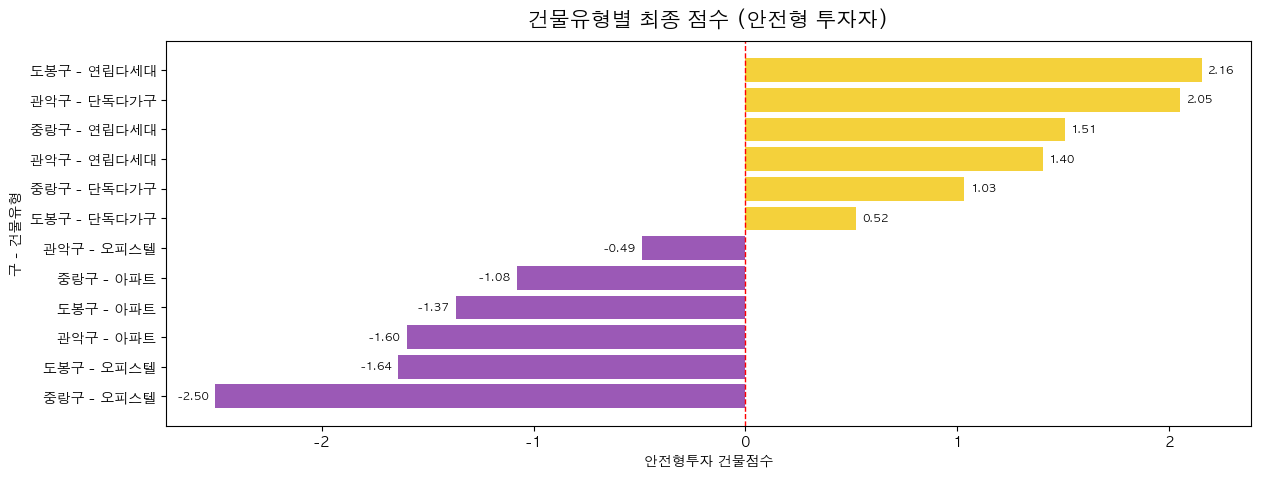

In [269]:
# 안전형 투자자 건물 유형별 최종 점수
df_safe_rank = safe_gu_rank[["자치구명", "건물용도", "안전형투자건물점수"]].copy()

df_safe_rank["라벨"] = df_safe_rank["자치구명"] + " - " + df_safe_rank["건물용도"]
df_safe_rank = df_safe_rank.sort_values("안전형투자건물점수", ascending = True).reset_index(drop = True)


colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in df_safe_rank["안전형투자건물점수"]]

# 시각화
plt.figure(figsize=(14, 5))
plt.barh(df_safe_rank["라벨"], df_safe_rank["안전형투자건물점수"], color=colors)

plt.title("건물유형별 최종 점수 (안전형 투자자)", fontsize=15, fontweight="bold", pad=10)
plt.xlabel("안전형투자 건물점수")
plt.ylabel("구 - 건물유형")

for i, v in enumerate(df_safe_rank["안전형투자건물점수"]):
    if v >= 0:
        ha = "left"
        x_pos = v + 0.03
    else:
        ha = "right"
        x_pos = v - 0.03
    plt.text(x_pos, i, f"{v:.2f}", va = "center", ha = ha, fontsize = 8)

plt.axvline(0, color="red", linestyle="--", linewidth = 1, label = "0") 

plt.show()

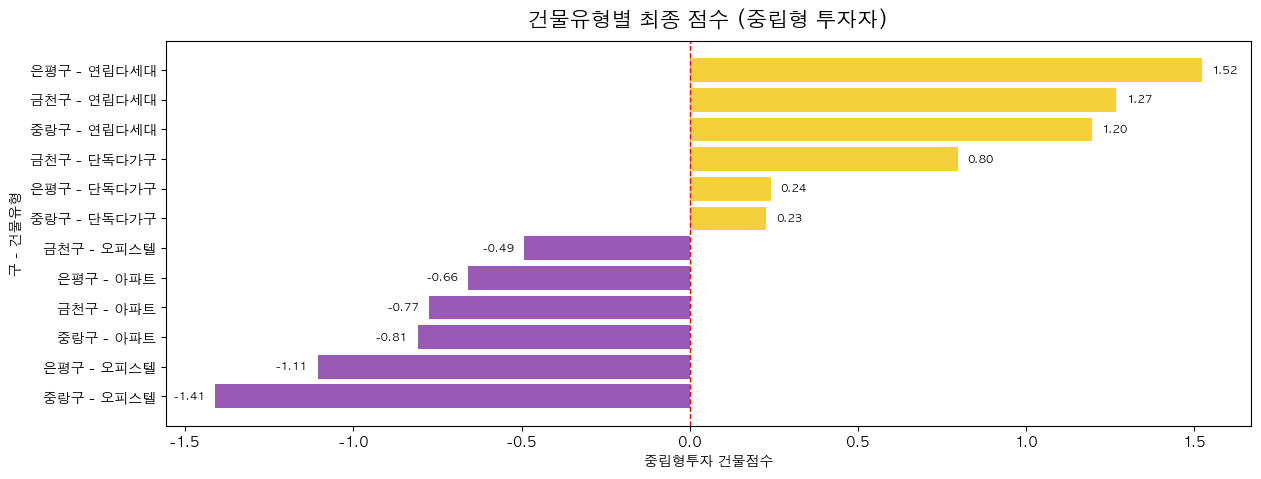

In [270]:
# 중립형 투자자 건물 유형별 최종 점수
df_neutral_rank = neutral_gu_rank[["자치구명", "건물용도", "중립형투자건물점수"]].copy()

df_neutral_rank["라벨"] = df_neutral_rank["자치구명"] + " - " + df_neutral_rank["건물용도"]
df_neutral_rank = df_neutral_rank.sort_values("중립형투자건물점수", ascending = True).reset_index(drop=True)

colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in df_neutral_rank["중립형투자건물점수"]]

plt.figure(figsize = (14, 5))
plt.barh(df_neutral_rank["라벨"], df_neutral_rank["중립형투자건물점수"], color = colors)

plt.title("건물유형별 최종 점수 (중립형 투자자)", fontsize=15, fontweight="bold", pad=10)
plt.xlabel("중립형투자 건물점수")
plt.ylabel("구 - 건물유형")

for i, v in enumerate(df_neutral_rank["중립형투자건물점수"]):
    if v >= 0:
        ha = "left"
        x_pos = v + 0.03
    else:
        ha = "right"
        x_pos = v - 0.03
    plt.text(x_pos, i, f"{v:.2f}", va = "center", ha = ha, fontsize = 8)

plt.axvline(0, color = "red", linestyle = "--", linewidth = 1)

plt.show()


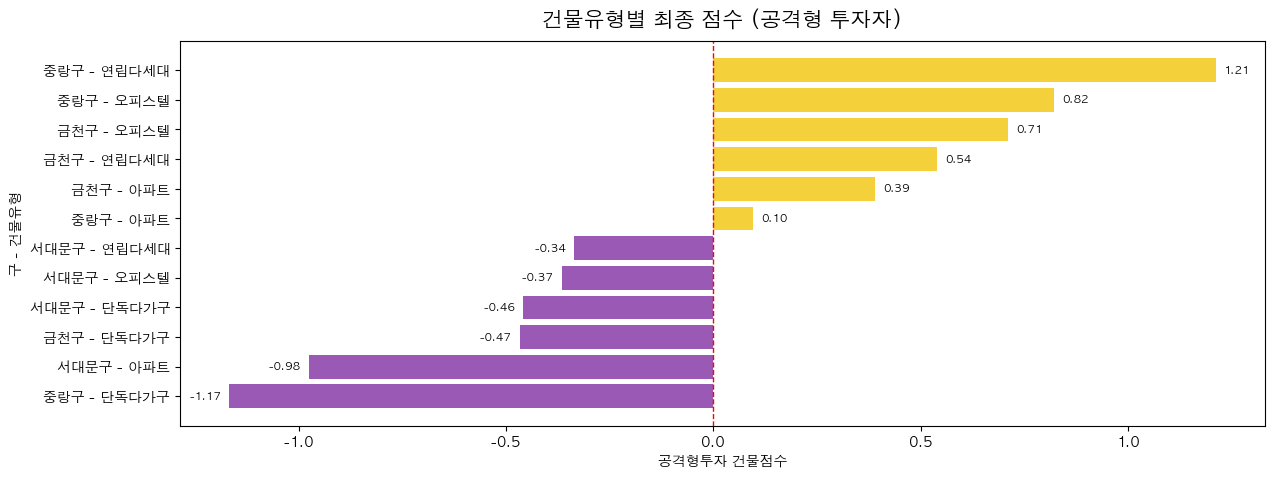

In [271]:
# 공격형 투자자 건물유형별 최종 점수
df_aggr_rank = aggr_gu_rank[["자치구명", "건물용도", "공격형투자건물점수"]].copy()

df_aggr_rank["라벨"] = df_aggr_rank["자치구명"] + " - " + df_aggr_rank["건물용도"]
df_aggr_rank = df_aggr_rank.sort_values("공격형투자건물점수", ascending = True).reset_index(drop = True)

colors = ["#F4D13B" if v >= 0 else "#9b59b6" for v in df_aggr_rank["공격형투자건물점수"]]

plt.figure(figsize=(14, 5))
plt.barh(df_aggr_rank["라벨"], df_aggr_rank["공격형투자건물점수"], color=colors)

plt.title("건물유형별 최종 점수 (공격형 투자자)", fontsize=15, fontweight="bold", pad=10)
plt.xlabel("공격형투자 건물점수")
plt.ylabel("구 - 건물유형")

for i, v in enumerate(df_aggr_rank["공격형투자건물점수"]):
    if v >= 0:
        ha = "left"
        x_pos = v + 0.02
    else:
        ha = "right"
        x_pos = v - 0.02
    plt.text(x_pos, i, f"{v:.2f}", va="center", ha = ha, fontsize = 8)

plt.axvline(0, color = "red", linestyle = "--", linewidth = 1)

plt.show()